## **Load and explore the network**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

!pip install cdlib
from cdlib import algorithms, evaluation
from cdlib.classes.node_clustering import NodeClustering
import random

# set seed for reproducibility
random.seed(1)
np.random.seed(1)

#  load southern women network
G_bip = nx.davis_southern_women_graph()

# basic info
print(f"Number of nodes: {G_bip.number_of_nodes()}")
print(f"Number of edges: {G_bip.number_of_edges()}")
print(f"Is directed: {nx.is_directed(G_bip)}")
print(f"Is bipartite: {nx.is_bipartite(G_bip)}")

# gets the two sets of nodes
women, events = nx.bipartite.sets(G_bip)
print(f"Number of women: {women}")
print(f"Number of events: {events}")
print(f"\nWomen: {sorted(women)}")
print(f"\nEvents: {sorted(events)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.4 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'bayanpy', 'leidenalg', 'wurlitzer', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'wurlitzer', 'infomap'}
Number of nodes: 32
Number of edges: 89
Is directed: False
Is bipartite: True
Number of women: {'Flora Price', 'Laura Mandeville', 'Verne Sanderson', 'Myra Liddel', 'Evelyn Jefferson', 'Olivia Carleton', 'Eleanor Nye', 'Dorothy Murchison', 'Ruth DeSand', 'Pearl Oglethorpe', 'Helen Lloy

## **Visualization of the network**

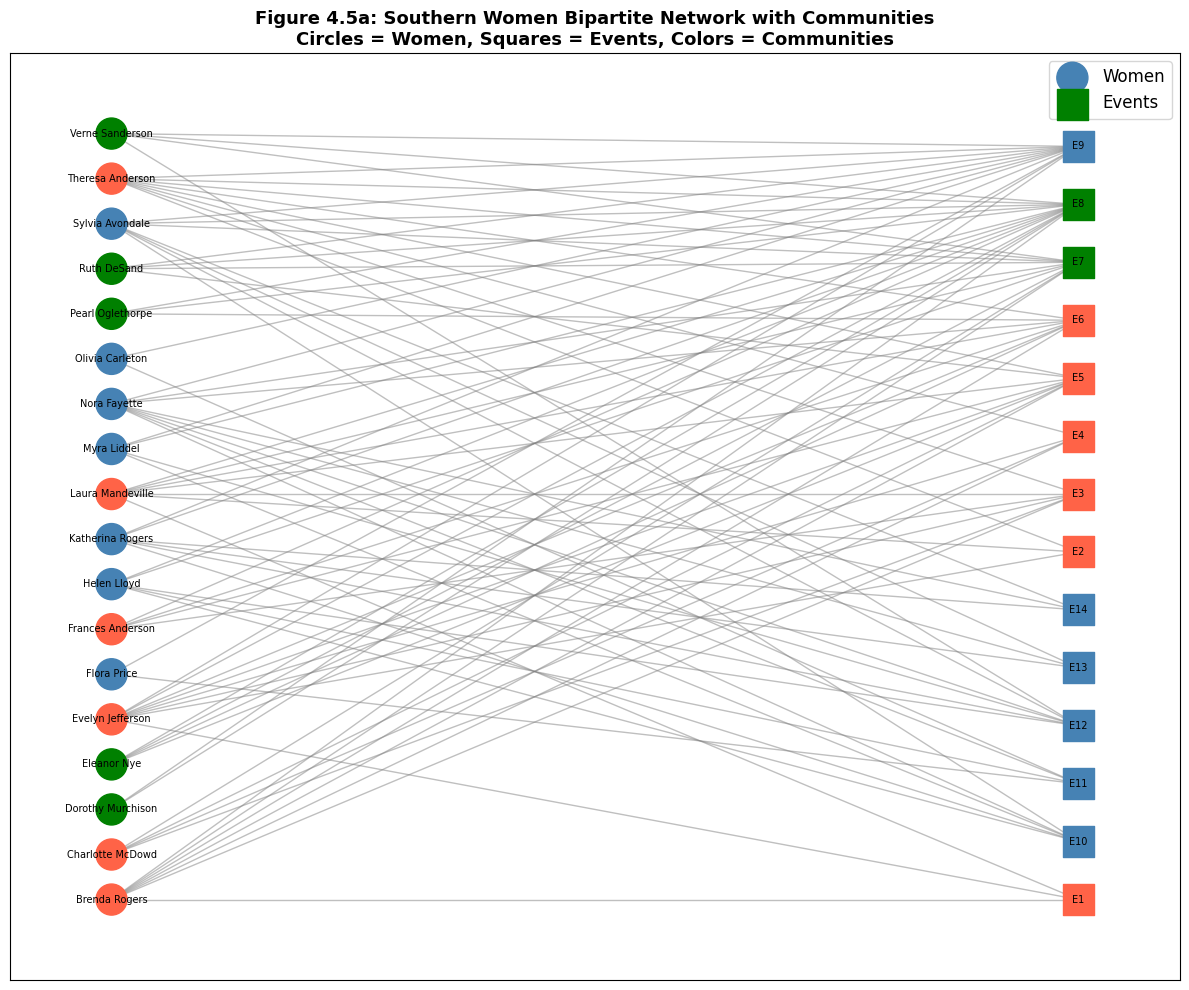

Communities found: 3
Community 1: 13 nodes
Community 2: 12 nodes
Community 3: 7 nodes


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from cdlib import algorithms

# Run Louvain on the bipartite graph
louvain_bip = algorithms.louvain(G_bip)

# Create node-to-community mapping
# {'Eleanor': 0, 'Brenda': 0, 'Event1': 1, 'Event2': 1}
node_to_community = {}
for community_id, community in enumerate(louvain_bip.communities):
    for node in community:
        node_to_community[node] = community_id

# Define colors for communities
simple_colors = ['steelblue', 'tomato', 'green', 'yellow', 'purple', 'orange']

# Separate Women and Events
women = {n for n, d in G_bip.nodes(data=True) if d.get('bipartite') == 0}
events = {n for n, d in G_bip.nodes(data=True) if d.get('bipartite') == 1}

# Create positions
# Women on the left (x=0) in a vertical line
# Events on the RIGHT (x=2) in a vertical line, scaled to match
pos = {}
women_list = sorted(women)
for i, woman in enumerate(women_list):
    pos[woman] = (0, i)
events_list = sorted(events)
for i, event in enumerate(events_list):
    pos[event] = (2, i * 18/14)

# Plot
plt.figure(figsize=(12, 10))

# Draw women as circles, colored by community
women_nodes = list(women)
women_colors = [simple_colors[node_to_community[node] % len(simple_colors)] for node in women_nodes]
nx.draw_networkx_nodes(G_bip, pos,
                       nodelist=women_nodes,
                       node_color=women_colors,
                       node_shape="o",  # circles
                       node_size=500,
                       label="Women")

# Draw events as squares, colored by community
events_nodes = list(events)
events_colors = [simple_colors[node_to_community[node] % len(simple_colors)] for node in events_nodes]
nx.draw_networkx_nodes(G_bip, pos,
                       nodelist=events_nodes,
                       node_color=events_colors,
                       node_shape="s",  # squares
                       node_size=500,
                       label="Events")

# Draw edges
nx.draw_networkx_edges(G_bip, pos,
                       edge_color="gray",
                       width=1,
                       alpha=0.5)

# Draw labels
nx.draw_networkx_labels(G_bip, pos,
                        font_size=7)

plt.legend(scatterpoints=1, fontsize=12)
plt.title(f"Figure 4.5a: Southern Women Bipartite Network with Communities\nCircles = Women, Squares = Events, Colors = Communities",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_4_5a_southern_women_bipartite_communities.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Communities found: {len(louvain_bip.communities)}")
for i, community in enumerate(louvain_bip.communities):
    print(f"Community {i+1}: {len(community)} nodes")

## **Run community detection:**

For bipartite networks, we test two different approaches:

**Option A - Run directly on the bipartite graph:**

We apply algorithms to all 32 nodes together (women and events).
This finds communities that mix both types of nodes.

**Option B - Project for women only:**

We create a new graph with only women as nodes. Two women connect
if they participate in the same event. Then we run algorithms on this new graph.


In [ ]:
# option A -> Direct on bipartite graph
print("Option A: Run directly on the bipartite graph")

# Convert string node labels to integers for algorithm compatibility
G_bip_int_nodes = nx.convert_node_labels_to_integers(G_bip, label_attribute='original_label')

louvain_bip = algorithms.louvain(G_bip)
infomap_bip = algorithms.infomap(G_bip_int_nodes) # Use the converted-label graph
walktrap_bip = algorithms.walktrap(G_bip_int_nodes) # Use the converted-label graph

print(f"Louvain: {len(louvain_bip.communities)} communities")
print(f"Infomap: {len(infomap_bip.communities)} communities")
print(f"Walktrap: {len(walktrap_bip.communities)} communities")
print("\n")

# option B -> project to women only
print("Option B: Project to women only")
# create projection (two women connected if they share an event)
G_bip_women = nx.bipartite.projected_graph(G_bip, women)


print(f"Projected graph nodes: {G_bip_women.number_of_nodes()}")
print(f"Projected graph edges: {G_bip_women.number_of_edges()}")

louvain_proj = algorithms.louvain(G_bip_women)
infomap_proj = algorithms.infomap(G_bip_women)
walktrap_proj = algorithms.walktrap(G_bip_women)

print(f"\nLouvain: {len(louvain_proj.communities)} communities")
print(f"Infomap: {len(infomap_proj.communities)} communities")
print(f"Walktrap: {len(walktrap_proj.communities)} communities")

Option A: Run directly on the bipartite graph
Louvain: 3 communities
Infomap: 2 communities
Walktrap: 2 communities


Option B: Project to women only
Projected graph nodes: 18
Projected graph edges: 139

Louvain: 2 communities
Infomap: 1 communities
Walktrap: 2 communities


## **Visualize the projected graph**

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# FIGURE 4.5b: LOUVAIN - PROJECTED NETWORK

# visualize projected graph with communities
pos = nx.spring_layout(G_bip_women, seed=1)

# color by Louvain communities (Option B)
colors = ["steelblue", "tomato", "seagreen"]
color_map = []
for node in G_bip_women.nodes():
    for i, comm in enumerate(louvain_proj.communities):
        if node in comm:
            color_map.append(colors[i])
            break

plt.figure(figsize=(12, 10))

# Draw the projected graph G_bip_women with community colors
nx.draw(G_bip_women, pos,
        node_color=color_map,
        with_labels=True,
        node_size=800,
        edge_color="gray",
        font_size=7,
        font_color="white")

plt.title("Figure 4.5b: Louvain Communities - Southern Women Projected Network\n2 communities of 9 women each",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_5b_southern_women_louvain.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.5b saved as 'figure_4_5b_southern_women_louvain.png'")

# print which women are in each community
print("\nLouvain communities (projected):")
for i, comm in enumerate(louvain_proj.communities):
    print(f"\nCommunity {i+1}:")
    for woman in sorted(comm):
        print(f"  {woman}")


AttributeError: 'list' object has no attribute 'get'

<Figure size 1200x1000 with 0 Axes>

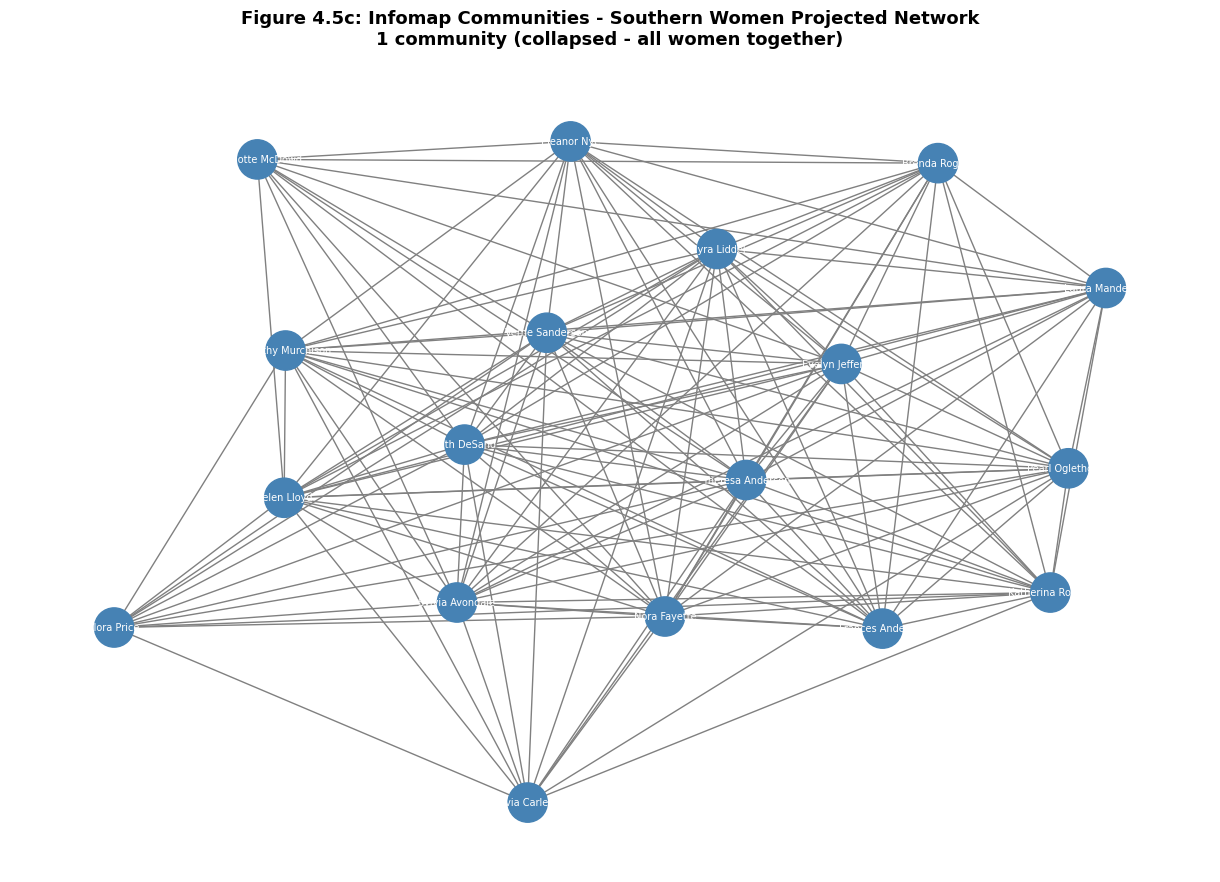

Figure 4.5c saved as 'figure_4_5c_southern_women_infomap.png'

Infomap communities (projected):

Community 1:
  Brenda Rogers
  Charlotte McDowd
  Dorothy Murchison
  Eleanor Nye
  Evelyn Jefferson
  Flora Price
  Frances Anderson
  Helen Lloyd
  Katherina Rogers
  Laura Mandeville
  Myra Liddel
  Nora Fayette
  Olivia Carleton
  Pearl Oglethorpe
  Ruth DeSand
  Sylvia Avondale
  Theresa Anderson
  Verne Sanderson


In [ ]:
# FIGURE 4.5c: INFOMAP - PROJECTED NETWORK
pos = nx.spring_layout(G_bip_women, seed=1)

# color by Infomap communities
color_map = []
for node in G_bip_women.nodes():
    for i, comm in enumerate(infomap_proj.communities):
        if node in comm:
            color_map.append(colors[i])
            break

plt.figure(figsize=(12, 8))
nx.draw(G_bip_women, pos,
        node_color=color_map,
        with_labels=True,
        node_size=800,
        edge_color="gray",
        font_size=7,
        font_color="white")
plt.title("Figure 4.5c: Infomap Communities - Southern Women Projected Network\n1 community (collapsed - all women together)",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_5c_southern_women_infomap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.5c saved as 'figure_4_5c_southern_women_infomap.png'")

# print which women are in each community
print("\nInfomap communities (projected):")
for i, comm in enumerate(infomap_proj.communities):
    print(f"\nCommunity {i+1}:")
    for woman in sorted(comm):
        print(f"  {woman}")

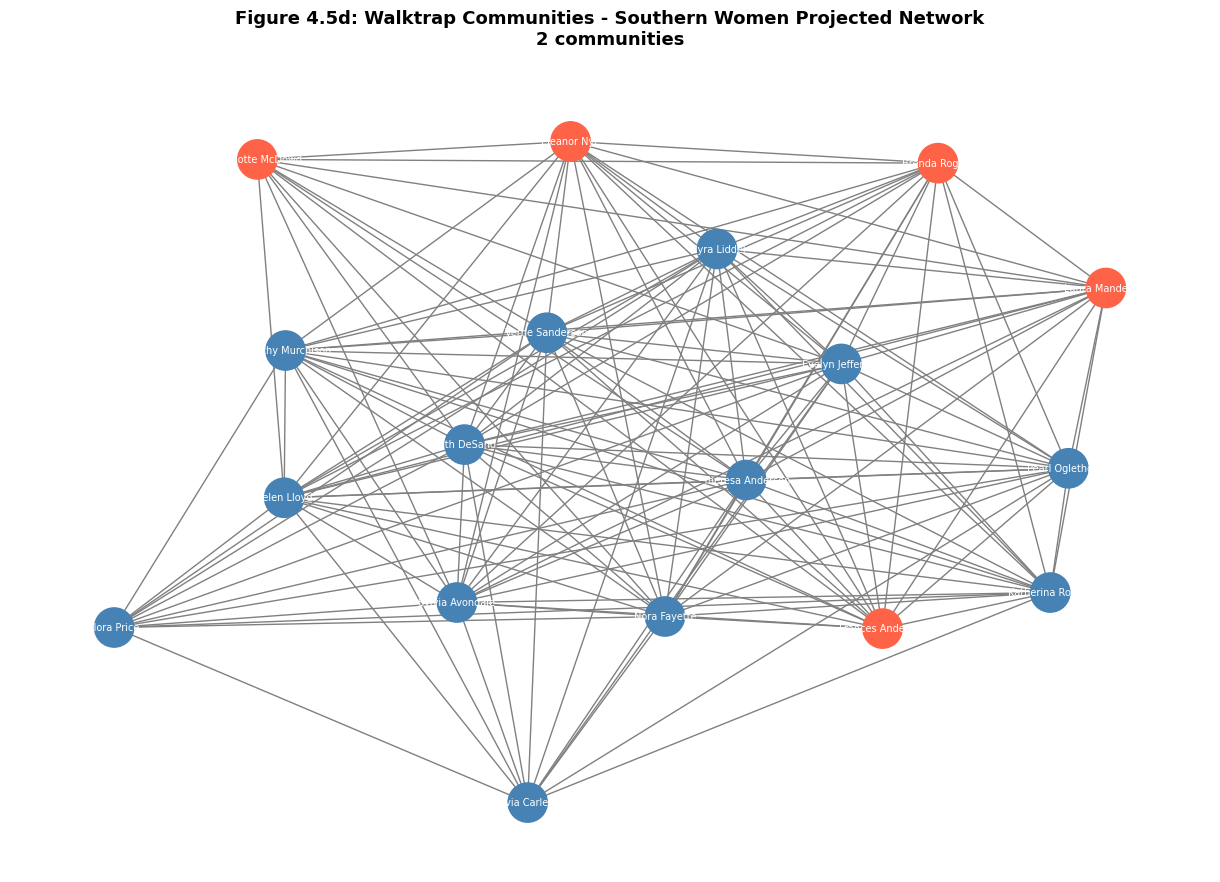

Figure 4.5d saved as 'figure_4_5d_southern_women_walktrap.png'

Walktrap communities (projected):

Community 1:
  Dorothy Murchison
  Evelyn Jefferson
  Flora Price
  Helen Lloyd
  Katherina Rogers
  Myra Liddel
  Nora Fayette
  Olivia Carleton
  Pearl Oglethorpe
  Ruth DeSand
  Sylvia Avondale
  Theresa Anderson
  Verne Sanderson

Community 2:
  Brenda Rogers
  Charlotte McDowd
  Eleanor Nye
  Frances Anderson
  Laura Mandeville


In [ ]:
# FIGURE 4.5d: WALKTRAP - PROJECTED NETWORK

pos = nx.spring_layout(G_bip_women, seed=1)

# color by Walktrap communities
color_map = []
for node in G_bip_women.nodes():
    for i, comm in enumerate(walktrap_proj.communities):
        if node in comm:
            color_map.append(colors[i])
            break

plt.figure(figsize=(12, 8))
nx.draw(G_bip_women, pos,
        node_color=color_map,
        with_labels=True,
        node_size=800,
        edge_color="gray",
        font_size=7,
        font_color="white")
plt.title("Figure 4.5d: Walktrap Communities - Southern Women Projected Network\n2 communities",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_5d_southern_women_walktrap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.5d saved as 'figure_4_5d_southern_women_walktrap.png'")

# print which women are in each community
print("\nWalktrap communities (projected):")
for i, comm in enumerate(walktrap_proj.communities):
    print(f"\nCommunity {i+1}:")
    for woman in sorted(comm):
        print(f"  {woman}")